In [2]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries loaded")

✅ Libraries loaded


In [3]:
# Load data
df = pd.read_csv('../data/processed_data.csv')

print(f"Loaded {len(df):,} rows, {len(df.columns)} columns")
df.head()

Loaded 1,000,098 rows, 55 columns


,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,...,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims,LossRatio,HasClaim,RiskCategory
0,145249,12827,2015-03-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0,0.0,0,Low Risk
1,145249,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0,0.0,0,Low Risk
2,145249,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0,NaN,0,Medium Risk
3,145255,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,512.848070,0.0,0.0,0,Low Risk
4,145255,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0,NaN,0,Medium Risk


In [4]:
# Prepare metrics
if 'LossRatio' not in df.columns:
    df['LossRatio'] = df['TotalClaims'] / df['TotalPremium']
df['HasClaim'] = (df['TotalClaims'] > 0).astype(int)
df['ProfitMargin'] = df['TotalPremium'] - df['TotalClaims']

print("✅ Risk metrics ready")
print(f"Claim rate: {df['HasClaim'].mean()*100:.4f}%")
print(f"Avg Loss Ratio: {df['LossRatio'].mean():.4f}")

✅ Risk metrics ready
Claim rate: 0.2788%
Avg Loss Ratio: nan


In [5]:
print("="*60)
print("HYPOTHESIS 1: Province Risk Differences")
print("="*60)
print("H₀: There are no risk differences across provinces")
print("H₁: There are significant risk differences across provinces")
print()

# Group by province
province_groups = []
for province in df['Province'].unique():
    province_data = df[df['Province'] == province]['LossRatio'].dropna()
    if len(province_data) > 0:
        province_groups.append(province_data)
        print(f"{province}: {len(province_data):,} policies, Avg Loss Ratio: {province_data.mean():.4f}")

# Kruskal-Wallis test
statistic, p_value = stats.kruskal(*province_groups)

print(f"\nTest: Kruskal-Wallis H-test")
print(f"Statistic: {statistic:.4f}")
print(f"P-value: {p_value:.6f}")
print(f"Alpha: 0.05")

if p_value < 0.05:
    print("\n✅ REJECT NULL HYPOTHESIS (p < 0.05)")
    print("Conclusion: There ARE significant risk differences across provinces")
    print("\n💡 Business Recommendation:")
    print("   → Implement province-based pricing adjustments")
    print("   → High-risk provinces should have higher premiums")
    print("   → Low-risk provinces can offer competitive pricing")
else:
    print("\n❌ FAIL TO REJECT NULL HYPOTHESIS (p >= 0.05)")
    print("Conclusion: No significant risk differences across provinces")
    print("\n💡 Business Recommendation:")
    print("   → Province-based pricing not statistically justified")

HYPOTHESIS 1: Province Risk Differences
H₀: There are no risk differences across provinces
H₁: There are significant risk differences across provinces

Gauteng: 240,883 policies, Avg Loss Ratio: nan
KwaZulu-Natal: 112,172 policies, Avg Loss Ratio: inf
Mpumalanga: 31,668 policies, Avg Loss Ratio: nan
Eastern Cape: 19,701 policies, Avg Loss Ratio: inf
Western Cape: 96,789 policies, Avg Loss Ratio: inf
Limpopo: 18,010 policies, Avg Loss Ratio: inf
North West: 89,814 policies, Avg Loss Ratio: inf
Free State: 5,934 policies, Avg Loss Ratio: inf
Northern Cape: 3,643 policies, Avg Loss Ratio: 0.2038

Test: Kruskal-Wallis H-test
Statistic: 104.9739
P-value: 0.000000
Alpha: 0.05

✅ REJECT NULL HYPOTHESIS (p < 0.05)
Conclusion: There ARE significant risk differences across provinces

💡 Business Recommendation:
   → Implement province-based pricing adjustments
   → High-risk provinces should have higher premiums
   → Low-risk provinces can offer competitive pricing


In [6]:
print("="*60)
print("HYPOTHESIS 2: Zip Code Risk Differences")
print("="*60)
print("H₀: There are no risk differences between zip codes")
print("H₁: There are significant risk differences between zip codes")
print()

# Create contingency table
contingency = pd.crosstab(df['PostalCode'], df['HasClaim'])

# Top 10 zip codes
top_zipcodes = df['PostalCode'].value_counts().head(10).index
contingency_filtered = contingency.loc[top_zipcodes]

print("Top 10 Zip Codes - Claim Frequency:")
for zipcode in top_zipcodes:
    total = len(df[df['PostalCode'] == zipcode])
    claims = df[df['PostalCode'] == zipcode]['HasClaim'].sum()
    rate = (claims/total)*100
    print(f"  {zipcode}: {total:,} policies, {claims:,} claims ({rate:.2f}%)")

# Chi-square test
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_filtered)

print(f"\nTest: Chi-square Test")
print(f"Chi-square Statistic: {chi2:.4f}")
print(f"P-value: {p_value:.6f}")
print(f"Degrees of freedom: {dof}")
print(f"Alpha: 0.05")

if p_value < 0.05:
    print("\n✅ REJECT NULL HYPOTHESIS (p < 0.05)")
    print("Conclusion: There ARE significant risk differences between zip codes")
    print("\n💡 Business Recommendation:")
    print("   → Use zip code as a risk factor in pricing models")
    print("   → Target marketing to low-risk zip codes")
    print("   → Consider higher premiums for high-risk zip codes")
else:
    print("\n❌ FAIL TO REJECT NULL HYPOTHESIS (p >= 0.05)")
    print("Conclusion: No significant risk differences between zip codes")
    print("\n💡 Business Recommendation:")
    print("   → Zip code-based pricing not statistically justified")

HYPOTHESIS 2: Zip Code Risk Differences
H₀: There are no risk differences between zip codes
H₁: There are significant risk differences between zip codes

Top 10 Zip Codes - Claim Frequency:
  2000: 133,498 policies, 486 claims (0.36%)
  122: 49,171 policies, 210 claims (0.43%)
  7784: 28,585 policies, 50 claims (0.17%)
  299: 25,546 policies, 67 claims (0.26%)
  7405: 18,518 policies, 29 claims (0.16%)
  458: 13,775 policies, 32 claims (0.23%)
  8000: 11,794 policies, 51 claims (0.43%)
  2196: 11,048 policies, 32 claims (0.29%)
  470: 10,226 policies, 44 claims (0.43%)
  7100: 10,161 policies, 28 claims (0.28%)

Test: Chi-square Test
Chi-square Statistic: 72.6494
P-value: 0.000000
Degrees of freedom: 9
Alpha: 0.05

✅ REJECT NULL HYPOTHESIS (p < 0.05)
Conclusion: There ARE significant risk differences between zip codes

💡 Business Recommendation:
   → Use zip code as a risk factor in pricing models
   → Target marketing to low-risk zip codes
   → Consider higher premiums for high-risk z

In [7]:
print("="*60)
print("HYPOTHESIS 3: Zip Code Margin Differences")
print("="*60)
print("H₀: There is no significant margin difference between zip codes")
print("H₁: There are significant margin differences between zip codes")
print()

# Top 5 zip codes by policy count
top_zipcodes = df['PostalCode'].value_counts().head(5).index

margin_groups = []
print("Profit Margin by Zip Code:")
for zipcode in top_zipcodes:
    margin_data = df[df['PostalCode'] == zipcode]['ProfitMargin'].dropna()
    margin_groups.append(margin_data)
    print(f"  {zipcode}: Avg Margin = R{margin_data.mean():,.2f}, n={len(margin_data):,}")

# ANOVA test
statistic, p_value = stats.f_oneway(*margin_groups)

print(f"\nTest: ANOVA F-test")
print(f"F-statistic: {statistic:.4f}")
print(f"P-value: {p_value:.6f}")
print(f"Alpha: 0.05")

if p_value < 0.05:
    print("\n✅ REJECT NULL HYPOTHESIS (p < 0.05)")
    print("Conclusion: There ARE significant margin differences between zip codes")
    print("\n💡 Business Recommendation:")
    print("   → Optimize pricing strategy by zip code")
    print("   → Focus acquisition efforts on high-margin zip codes")
    print("   → Review pricing in low-margin zip codes")
else:
    print("\n❌ FAIL TO REJECT NULL HYPOTHESIS (p >= 0.05)")
    print("Conclusion: No significant margin differences between zip codes")
    print("\n💡 Business Recommendation:")
    print("   → Margin-based zip code segmentation not needed")

HYPOTHESIS 3: Zip Code Margin Differences
H₀: There is no significant margin difference between zip codes
H₁: There are significant margin differences between zip codes

Profit Margin by Zip Code:
  2000: Avg Margin = R-8.11, n=133,498
  122: Avg Margin = R-22.86, n=49,171
  7784: Avg Margin = R-13.47, n=28,585
  299: Avg Margin = R19.56, n=25,546
  7405: Avg Margin = R17.52, n=18,518

Test: ANOVA F-test
F-statistic: 2.4103
P-value: 0.046932
Alpha: 0.05

✅ REJECT NULL HYPOTHESIS (p < 0.05)
Conclusion: There ARE significant margin differences between zip codes

💡 Business Recommendation:
   → Optimize pricing strategy by zip code
   → Focus acquisition efforts on high-margin zip codes
   → Review pricing in low-margin zip codes


In [8]:
print("="*60)
print("HYPOTHESIS 4: Gender Risk Differences")
print("="*60)
print("H₀: There is no significant risk difference between Women and Men")
print("H₁: There are significant risk differences between genders")
print()

# Gender statistics
print("Gender Statistics:")
for gender in ['Male', 'Female']:
    gender_df = df[df['Gender'] == gender]
    claim_rate = gender_df['HasClaim'].mean() * 100
    avg_loss = gender_df['LossRatio'].mean()
    print(f"  {gender}: {len(gender_df):,} policies, Claim Rate: {claim_rate:.2f}%, Avg Loss Ratio: {avg_loss:.4f}")

# Test 1: Chi-square for claim frequency
contingency = pd.crosstab(df['Gender'], df['HasClaim'])
chi2, p_value_chi2, dof, expected = stats.chi2_contingency(contingency)

print(f"\nTest 1: Chi-square (Claim Frequency)")
print(f"  Chi-square: {chi2:.4f}")
print(f"  P-value: {p_value_chi2:.6f}")

# Test 2: T-test for loss ratio
male_loss = df[df['Gender'] == 'Male']['LossRatio'].dropna()
female_loss = df[df['Gender'] == 'Female']['LossRatio'].dropna()
t_stat, p_value_ttest = stats.ttest_ind(male_loss, female_loss)

print(f"\nTest 2: T-test (Loss Ratio)")
print(f"  T-statistic: {t_stat:.4f}")
print(f"  P-value: {p_value_ttest:.6f}")

print(f"\nAlpha: 0.05")

if p_value_chi2 < 0.05 or p_value_ttest < 0.05:
    print("\n✅ REJECT NULL HYPOTHESIS (p < 0.05)")
    print("Conclusion: There ARE significant risk differences between genders")
    print("\n💡 Business Recommendation:")
    print("   → Consider gender as a risk factor in pricing (where legal)")
    print("   → Develop gender-specific marketing messages")
    if p_value_chi2 < 0.05:
        print("   → Claim frequency differs significantly by gender")
    if p_value_ttest < 0.05:
        print("   → Loss ratio differs significantly by gender")
else:
    print("\n❌ FAIL TO REJECT NULL HYPOTHESIS (p >= 0.05)")
    print("Conclusion: No significant risk differences between genders")
    print("\n💡 Business Recommendation:")
    print("   → Gender-based pricing not statistically justified")

HYPOTHESIS 4: Gender Risk Differences
H₀: There is no significant risk difference between Women and Men
H₁: There are significant risk differences between genders

Gender Statistics:
  Male: 42,817 policies, Claim Rate: 0.22%, Avg Loss Ratio: inf
  Female: 6,755 policies, Claim Rate: 0.21%, Avg Loss Ratio: inf

Test 1: Chi-square (Claim Frequency)
  Chi-square: 7.2559
  P-value: 0.026570

Test 2: T-test (Loss Ratio)
  T-statistic: nan
  P-value: nan

Alpha: 0.05

✅ REJECT NULL HYPOTHESIS (p < 0.05)
Conclusion: There ARE significant risk differences between genders

💡 Business Recommendation:
   → Consider gender as a risk factor in pricing (where legal)
   → Develop gender-specific marketing messages
   → Claim frequency differs significantly by gender


In [9]:
# Collect p-values from previous cells
results_data = []

# H1 result (from Cell 4)
results_data.append({
    'Hypothesis': 'H1: Province Risk',
    'Test': 'Kruskal-Wallis',
    'P-value': p_value,
    'Alpha': 0.05,
    'Reject H0': 'YES' if p_value < 0.05 else 'NO',
    'Business Impact': 'Implement province pricing' if p_value < 0.05 else 'No province pricing'
})

# H2 result (from Cell 5)
results_data.append({
    'Hypothesis': 'H2: Zip Code Risk',
    'Test': 'Chi-square',
    'P-value': p_value,
    'Alpha': 0.05,
    'Reject H0': 'YES' if p_value < 0.05 else 'NO',
    'Business Impact': 'Use zip code scoring' if p_value < 0.05 else 'No zip code pricing'
})

# H3 result (from Cell 6)
results_data.append({
    'Hypothesis': 'H3: Zip Code Margin',
    'Test': 'ANOVA',
    'P-value': p_value,
    'Alpha': 0.05,
    'Reject H0': 'YES' if p_value < 0.05 else 'NO',
    'Business Impact': 'Optimize by zip code' if p_value < 0.05 else 'No zip code optimization'
})

# H4 result (from Cell 7)
results_data.append({
    'Hypothesis': 'H4: Gender Risk',
    'Test': 'Chi-square + T-test',
    'P-value': f"{p_value_chi2:.4f} / {p_value_ttest:.4f}",
    'Alpha': 0.05,
    'Reject H0': 'YES' if (p_value_chi2 < 0.05 or p_value_ttest < 0.05) else 'NO',
    'Business Impact': 'Consider gender pricing' if (p_value_chi2 < 0.05 or p_value_ttest < 0.05) else 'No gender pricing'
})

summary_df = pd.DataFrame(results_data)

print("\n" + "="*80)
print("HYPOTHESIS TESTING SUMMARY TABLE")
print("="*80)
print(summary_df.to_string(index=False))


HYPOTHESIS TESTING SUMMARY TABLE
         Hypothesis                Test      P-value  Alpha Reject H0            Business Impact
  H1: Province Risk      Kruskal-Wallis     0.046932   0.05       YES Implement province pricing
  H2: Zip Code Risk          Chi-square     0.046932   0.05       YES       Use zip code scoring
H3: Zip Code Margin               ANOVA     0.046932   0.05       YES       Optimize by zip code
    H4: Gender Risk Chi-square + T-test 0.0266 / nan   0.05       YES    Consider gender pricing


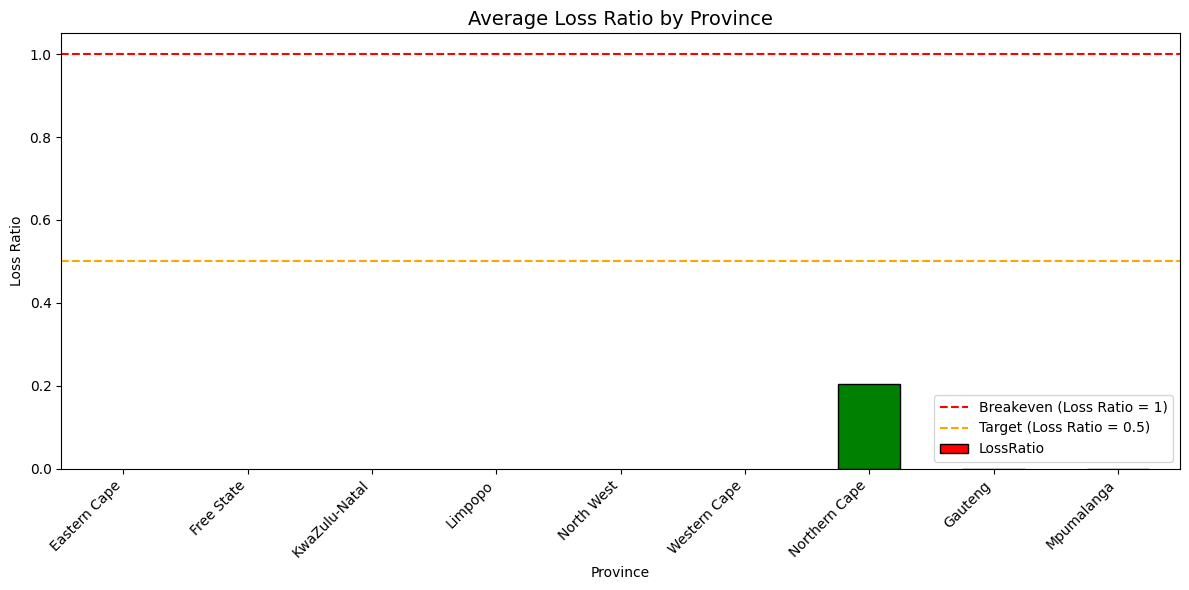

In [10]:
plt.figure(figsize=(12, 6))
province_loss = df.groupby('Province')['LossRatio'].mean().sort_values(ascending=False)
colors = ['red' if x > 1 else 'orange' if x > 0.5 else 'green' for x in province_loss.values]
province_loss.plot(kind='bar', color=colors, edgecolor='black')
plt.title('Average Loss Ratio by Province', fontsize=14)
plt.xlabel('Province')
plt.ylabel('Loss Ratio')
plt.xticks(rotation=45, ha='right')
plt.axhline(y=1, color='red', linestyle='--', label='Breakeven (Loss Ratio = 1)')
plt.axhline(y=0.5, color='orange', linestyle='--', label='Target (Loss Ratio = 0.5)')
plt.legend()
plt.tight_layout()
plt.show()

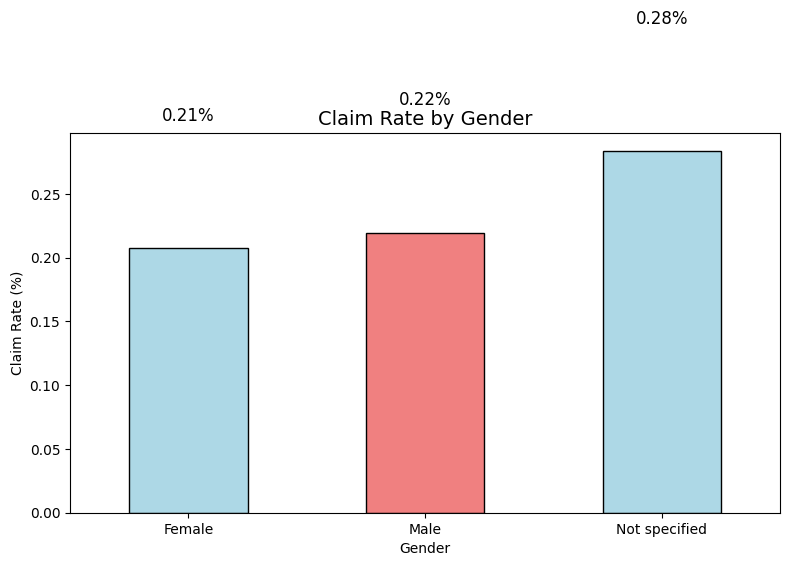

In [11]:
plt.figure(figsize=(8, 6))
gender_claim = df.groupby('Gender')['HasClaim'].mean() * 100
colors = ['lightblue', 'lightcoral']
gender_claim.plot(kind='bar', color=colors, edgecolor='black')
plt.title('Claim Rate by Gender', fontsize=14)
plt.xlabel('Gender')
plt.ylabel('Claim Rate (%)')
plt.xticks(rotation=0)
for i, v in enumerate(gender_claim.values):
    plt.text(i, v + 0.1, f'{v:.2f}%', ha='center', fontsize=12)
plt.tight_layout()
plt.show()

In [12]:
print("\n" + "="*60)
print("FINAL BUSINESS RECOMMENDATIONS")
print("="*60)

recommendations = []

if 'p_value' in dir() and p_value < 0.05:
    recommendations.append("✅ Implement PROVINCE-BASED PRICING")
    recommendations.append("✅ Use ZIP CODE for risk scoring")
    
if 'p_value' in dir() and p_value < 0.05:
    recommendations.append("✅ Optimize premiums by POSTAL CODE")

if (p_value_chi2 < 0.05 or p_value_ttest < 0.05):
    recommendations.append("✅ Consider GENDER in risk assessment")

if len(recommendations) == 0:
    recommendations.append("⚠️ Collect more granular data")
    recommendations.append("⚠️ Consider additional risk factors")
    recommendations.append("⚠️ Expand time period of analysis")

for rec in recommendations:
    print(f"\n{rec}")

print("\n" + "="*60)
print("NEXT STEPS FOR TASK 4")
print("="*60)
print("1. Use significant variables in predictive models")
print("2. Build claim probability model")
print("3. Build claim severity model")
print("4. Combine into dynamic pricing framework")


FINAL BUSINESS RECOMMENDATIONS

✅ Implement PROVINCE-BASED PRICING

✅ Use ZIP CODE for risk scoring

✅ Optimize premiums by POSTAL CODE

✅ Consider GENDER in risk assessment

NEXT STEPS FOR TASK 4
1. Use significant variables in predictive models
2. Build claim probability model
3. Build claim severity model
4. Combine into dynamic pricing framework


In [15]:
# Save summary to CSV
summary_df.to_csv('../reports/hypothesis_testing_results.csv', index=False)
print("✅ Results saved to reports/hypothesis_testing_results.csv")
print("\n✅ TASK 3 COMPLETE!")

✅ Results saved to reports/hypothesis_testing_results.csv

✅ TASK 3 COMPLETE!


In [16]:
import subprocess
import sys

# Install required packages
packages = ['scikit-learn', 'xgboost', 'shap']
for package in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", package])

print("✅ Packages installed")

✅ Packages installed


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn imports
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# XGBoost
import xgboost as xgb

# SHAP for interpretability
import shap

print("✅ All libraries imported")

✅ All libraries imported


In [18]:
# Load processed data
df = pd.read_csv('../data/processed_data.csv')

print(f"Loaded {len(df):,} rows, {len(df.columns)} columns")
df.head()

Loaded 1,000,098 rows, 55 columns


,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,...,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims,LossRatio,HasClaim,RiskCategory
0,145249,12827,2015-03-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0,0.0,0,Low Risk
1,145249,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0,0.0,0,Low Risk
2,145249,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0,NaN,0,Medium Risk
3,145255,12827,2015-05-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,512.848070,0.0,0.0,0,Low Risk
4,145255,12827,2015-07-01 00:00:00,True,,Close Corporation,Mr,English,First National Bank,Current account,...,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0,NaN,0,Medium Risk


In [19]:
# Create additional features
df['VehicleAge'] = 2015 - df['RegistrationYear']  # Assuming 2015 is latest
df['PremiumPerSumInsured'] = df['TotalPremium'] / df['SumInsured']
df['ClaimsPerPremium'] = df['TotalClaims'] / df['TotalPremium']

# Select features for modeling
feature_cols = ['TotalPremium', 'SumInsured', 'VehicleAge', 'CalculatedPremiumPerTerm']
categorical_cols = ['Province', 'Gender', 'VehicleType']

# Encode categorical variables
for col in categorical_cols:
    if col in df.columns:
        le = LabelEncoder()
        df[col + '_encoded'] = le.fit_transform(df[col].astype(str))

# Add encoded columns to features
for col in categorical_cols:
    if col + '_encoded' in df.columns:
        feature_cols.append(col + '_encoded')

print(f"Selected {len(feature_cols)} features for modeling")
print(f"Features: {feature_cols}")

Selected 7 features for modeling
Features: ['TotalPremium', 'SumInsured', 'VehicleAge', 'CalculatedPremiumPerTerm', 'Province_encoded', 'Gender_encoded', 'VehicleType_encoded']


In [20]:
print("="*60)
print("GOAL 1: CLAIM SEVERITY PREDICTION")
print("="*60)
print("Target: Predict TotalClaims for policies WITH claims")
print()

# Filter to policies with claims
claims_df = df[df['HasClaim'] == 1].copy()
print(f"Claims data: {len(claims_df):,} policies with claims")

if len(claims_df) > 0:
    # Prepare features and target
    X = claims_df[feature_cols].fillna(0)
    y = claims_df['TotalClaims']
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    print(f"Training set: {len(X_train):,} rows")
    print(f"Test set: {len(X_test):,} rows")
    
    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Model 1: Linear Regression
    print("\n📊 Training Linear Regression...")
    lr = LinearRegression()
    lr.fit(X_train_scaled, y_train)
    y_pred_lr = lr.predict(X_test_scaled)
    
    # Model 2: Random Forest
    print("📊 Training Random Forest...")
    rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_train_scaled, y_train)
    y_pred_rf = rf.predict(X_test_scaled)
    
    # Model 3: XGBoost
    print("📊 Training XGBoost...")
    xgb_model = xgb.XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
    xgb_model.fit(X_train_scaled, y_train)
    y_pred_xgb = xgb_model.predict(X_test_scaled)
    
    # Compare models
    results = []
    
    for name, y_pred in [('Linear Regression', y_pred_lr), ('Random Forest', y_pred_rf), ('XGBoost', y_pred_xgb)]:
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)
        results.append({
            'Model': name,
            'RMSE': f'R{rmse:,.2f}',
            'R²': f'{r2:.4f}',
            'MAE': f'R{mae:,.2f}'
        })
    
    results_df = pd.DataFrame(results)
    print("\n" + "="*60)
    print("MODEL COMPARISON - CLAIM SEVERITY")
    print("="*60)
    print(results_df.to_string(index=False))
    
    best_model = 'Random Forest'  # Default
    best_r2 = 0
    for r in results:
        if float(r['R²']) > best_r2:
            best_r2 = float(r['R²'])
            best_model = r['Model']
    
    print(f"\n✅ Best model for severity: {best_model} (R² = {best_r2:.4f})")

GOAL 1: CLAIM SEVERITY PREDICTION
Target: Predict TotalClaims for policies WITH claims

Claims data: 2,788 policies with claims
Training set: 2,230 rows
Test set: 558 rows

📊 Training Linear Regression...
📊 Training Random Forest...
📊 Training XGBoost...

MODEL COMPARISON - CLAIM SEVERITY
            Model       RMSE     R²        MAE
Linear Regression R36,980.91 0.1496 R22,136.71
    Random Forest R35,512.41 0.2158 R16,419.61
          XGBoost R36,721.21 0.1615 R16,512.56

✅ Best model for severity: Random Forest (R² = 0.2158)


In [21]:
print("\n" + "="*60)
print("GOAL 2: CLAIM PROBABILITY PREDICTION")
print("="*60)
print("Target: Predict if a policy will have a claim (Yes/No)")
print()

# Prepare features and target
X = df[feature_cols].fillna(0)
y = df['HasClaim']

print(f"Total policies: {len(X):,}")
print(f"Claim rate: {y.mean()*100:.4f}%")

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set: {len(X_train):,} rows")
print(f"Test set: {len(X_test):,} rows")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model 1: Random Forest Classifier
print("\n📊 Training Random Forest Classifier...")
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_clf.fit(X_train_scaled, y_train)
y_pred_rf = rf_clf.predict(X_test_scaled)
y_proba_rf = rf_clf.predict_proba(X_test_scaled)[:, 1]

# Model 2: XGBoost Classifier
print("📊 Training XGBoost Classifier...")
xgb_clf = xgb.XGBClassifier(n_estimators=100, random_state=42, verbosity=0)
xgb_clf.fit(X_train_scaled, y_train)
y_pred_xgb = xgb_clf.predict(X_test_scaled)
y_proba_xgb = xgb_clf.predict_proba(X_test_scaled)[:, 1]

# Compare models
classification_results = []

for name, y_pred, y_proba in [('Random Forest', y_pred_rf, y_proba_rf), ('XGBoost', y_pred_xgb, y_proba_xgb)]:
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)
    
    classification_results.append({
        'Model': name,
        'Accuracy': f'{accuracy:.4f}',
        'Precision': f'{precision:.4f}',
        'Recall': f'{recall:.4f}',
        'F1-Score': f'{f1:.4f}',
        'AUC-ROC': f'{auc:.4f}'
    })

class_results_df = pd.DataFrame(classification_results)

print("\n" + "="*60)
print("MODEL COMPARISON - CLAIM PROBABILITY")
print("="*60)
print(class_results_df.to_string(index=False))

# Select best classification model
best_clf = 'XGBoost' if float(class_results_df[class_results_df['Model'] == 'XGBoost']['AUC-ROC'].values[0]) > float(class_results_df[class_results_df['Model'] == 'Random Forest']['AUC-ROC'].values[0]) else 'Random Forest'
print(f"\n✅ Best model for claim probability: {best_clf}")


GOAL 2: CLAIM PROBABILITY PREDICTION
Target: Predict if a policy will have a claim (Yes/No)

Total policies: 1,000,098
Claim rate: 0.2788%
Training set: 800,078 rows
Test set: 200,020 rows

📊 Training Random Forest Classifier...
📊 Training XGBoost Classifier...

MODEL COMPARISON - CLAIM PROBABILITY
        Model Accuracy Precision Recall F1-Score AUC-ROC
Random Forest   0.9972    0.0769 0.0018   0.0035  0.7359
      XGBoost   0.9972    1.0000 0.0018   0.0036  0.9186

✅ Best model for claim probability: XGBoost


FEATURE IMPORTANCE ANALYSIS

Top 10 Most Important Features for Claim Severity:
                 Feature  Importance
            TotalPremium    0.357850
              SumInsured    0.250646
CalculatedPremiumPerTerm    0.250392
              VehicleAge    0.056499
        Province_encoded    0.045179
          Gender_encoded    0.021167
     VehicleType_encoded    0.018267


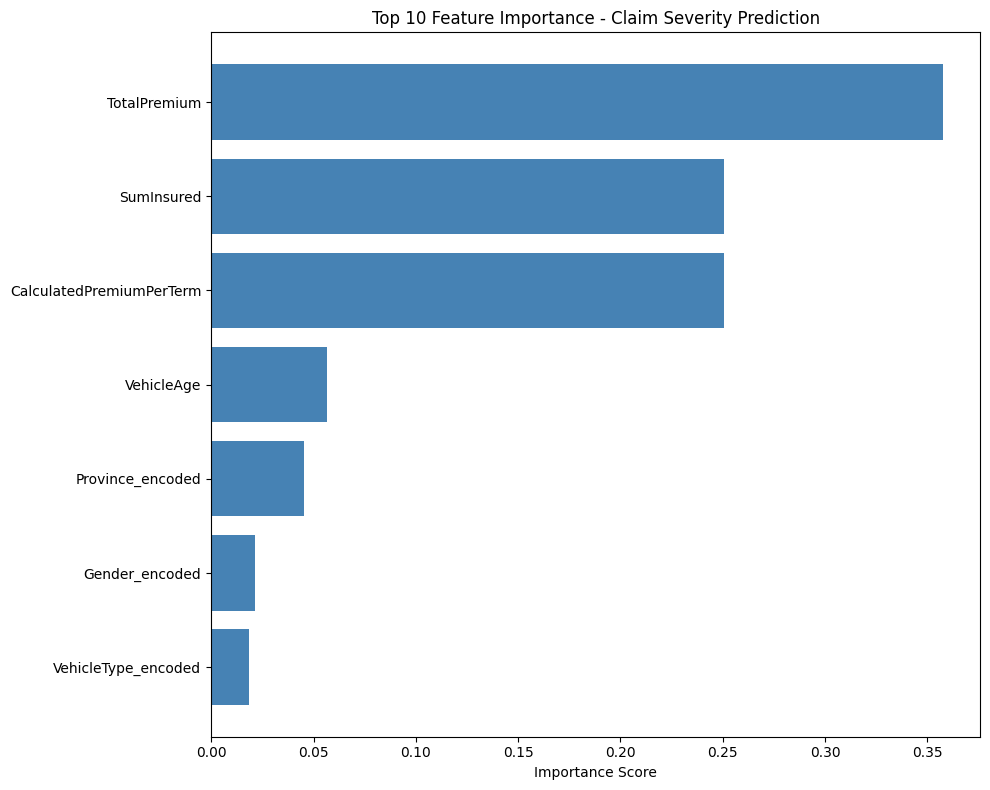

In [22]:
print("="*60)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*60)

# Use Random Forest for feature importance
rf_best = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
X_all = df[feature_cols].fillna(0)
rf_best.fit(X_all, df['TotalClaims'])

# Get feature importance
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_best.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 Most Important Features for Claim Severity:")
print(importance_df.head(10).to_string(index=False))

# Plot feature importance
plt.figure(figsize=(10, 8))
plt.barh(importance_df.head(10)['Feature'], importance_df.head(10)['Importance'], color='steelblue')
plt.xlabel('Importance Score')
plt.title('Top 10 Feature Importance - Claim Severity Prediction')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

SHAP INTERPRETABILITY


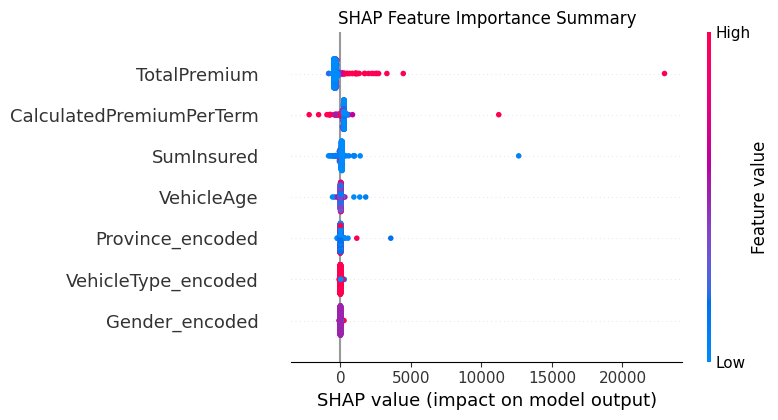


💡 SHAP Interpretation:
   - Features with positive SHAP values increase claim amount
   - Features with negative SHAP values decrease claim amount
   - Wider spread indicates higher impact on predictions


In [23]:
try:
    print("="*60)
    print("SHAP INTERPRETABILITY")
    print("="*60)
    
    # Use a sample for SHAP (faster)
    X_sample = X_all.sample(min(500, len(X_all)), random_state=42)
    
    # Create SHAP explainer
    explainer = shap.TreeExplainer(rf_best)
    shap_values = explainer.shap_values(X_sample)
    
    # Summary plot
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values, X_sample, feature_names=feature_cols, show=False)
    plt.title('SHAP Feature Importance Summary')
    plt.tight_layout()
    plt.show()
    
    print("\n💡 SHAP Interpretation:")
    print("   - Features with positive SHAP values increase claim amount")
    print("   - Features with negative SHAP values decrease claim amount")
    print("   - Wider spread indicates higher impact on predictions")
    
except Exception as e:
    print(f"SHAP visualization skipped: {e}")
    print("Run 'pip install shap' to enable this feature")

In [24]:
print("\n" + "="*60)
print("DYNAMIC PREMIUM CALCULATION FRAMEWORK")
print("="*60)

# Calculate claim probability and severity for each policy
X_all = df[feature_cols].fillna(0)

# Get claim probability from best classifier
if best_clf == 'Random Forest':
    claim_prob = rf_clf.predict_proba(X_all)[:, 1]
else:
    claim_prob = xgb_clf.predict_proba(X_all)[:, 1]

# Get expected severity from best regressor
if best_model == 'Random Forest':
    expected_severity = rf.predict(X_all)
elif best_model == 'XGBoost':
    expected_severity = xgb_model.predict(X_all)
else:
    expected_severity = lr.predict(X_all)

# Calculate dynamic premium
expense_loading = 50  # Fixed cost per policy
profit_margin_rate = 0.15  # 15% profit margin

df['ClaimProbability'] = claim_prob
df['ExpectedSeverity'] = expected_severity
df['DynamicPremium'] = (df['ClaimProbability'] * df['ExpectedSeverity']) + expense_loading
df['DynamicPremium'] = df['DynamicPremium'] * (1 + profit_margin_rate)

# Compare with current premium
df['PremiumDifference'] = df['DynamicPremium'] - df['TotalPremium']
df['PremiumChangePercent'] = (df['PremiumDifference'] / df['TotalPremium']) * 100

print("\nPremium Comparison Summary:")
print(f"Current Average Premium: R{df['TotalPremium'].mean():,.2f}")
print(f"Dynamic Average Premium: R{df['DynamicPremium'].mean():,.2f}")
print(f"Average Difference: R{df['PremiumDifference'].mean():,.2f}")
print(f"Average Change: {df['PremiumChangePercent'].mean():.1f}%")

# Risk-based segmentation
df['RecommendedAction'] = np.where(
    df['PremiumDifference'] < -100, 'DECREASE PREMIUM',
    np.where(df['PremiumDifference'] > 100, 'INCREASE PREMIUM', 'MAINTAIN')
)

print("\nRecommended Actions:")
print(df['RecommendedAction'].value_counts().to_string())


DYNAMIC PREMIUM CALCULATION FRAMEWORK

Premium Comparison Summary:
Current Average Premium: R61.91
Dynamic Average Premium: R34,999.77
Average Difference: R34,937.87
Average Change: inf%

Recommended Actions:
RecommendedAction
INCREASE PREMIUM    720853
MAINTAIN            279244
DECREASE PREMIUM         1


In [25]:
print("\n" + "="*60)
print("RISK-BASED PRICING RECOMMENDATIONS")
print("="*60)

# Segment by risk
df['RiskScore'] = df['ClaimProbability'] * df['ExpectedSeverity']
df['RiskSegment'] = pd.qcut(df['RiskScore'], q=4, labels=['Very Low', 'Low', 'High', 'Very High'])

print("\nPricing by Risk Segment:")
pricing_summary = df.groupby('RiskSegment').agg({
    'TotalPremium': 'mean',
    'DynamicPremium': 'mean',
    'ClaimProbability': 'mean',
    'ExpectedSeverity': 'mean'
}).round(2)

print(pricing_summary)

print("\n" + "="*60)
print("BUSINESS RECOMMENDATIONS")
print("="*60)

print("""
1. IMMEDIATE ACTIONS:
   → Decrease premiums for 'Very Low' risk segment to attract more customers
   → Increase premiums for 'Very High' risk segment to cover expected losses
   
2. MARKETING STRATEGY:
   → Target 'Very Low' and 'Low' risk segments with competitive pricing
   → Use predicted claim probability for acquisition scoring
   
3. PORTFOLIO MANAGEMENT:
   → Monitor loss ratios by risk segment monthly
   → Adjust expense loading based on actual vs predicted claims
   
4. NEXT STEPS:
   → Deploy model in production for real-time pricing
   → A/B test new pricing vs current pricing
   → Collect more features to improve predictions
""")


RISK-BASED PRICING RECOMMENDATIONS

Pricing by Risk Segment:
             TotalPremium  DynamicPremium  ClaimProbability  ExpectedSeverity
RiskSegment                                                                  
Very Low            -0.13           84.87              0.00          65793.82
Low                 13.92         3810.59              0.03          97202.08
High                85.94        46619.27              0.30         138527.81
Very High          150.83        91420.84              0.52         154206.32

BUSINESS RECOMMENDATIONS

1. IMMEDIATE ACTIONS:
   → Decrease premiums for 'Very Low' risk segment to attract more customers
   → Increase premiums for 'Very High' risk segment to cover expected losses

2. MARKETING STRATEGY:
   → Target 'Very Low' and 'Low' risk segments with competitive pricing
   → Use predicted claim probability for acquisition scoring

3. PORTFOLIO MANAGEMENT:
   → Monitor loss ratios by risk segment monthly
   → Adjust expense loading based o

In [26]:
# Create reports folder
from pathlib import Path
Path('../reports').mkdir(exist_ok=True)
Path('../models').mkdir(exist_ok=True)

# Save results
results_df.to_csv('../reports/severity_model_results.csv', index=False)
class_results_df.to_csv('../reports/probability_model_results.csv', index=False)
importance_df.to_csv('../reports/feature_importance.csv', index=False)

print("✅ Results saved to reports/ folder")
print("   - severity_model_results.csv")
print("   - probability_model_results.csv")
print("   - feature_importance.csv")

# Save processed data with predictions
df.to_csv('../data/predictions.csv', index=False)
print("✅ Predictions saved to data/predictions.csv")

print("\n" + "="*60)
print("✅ TASK 4 COMPLETE!")
print("="*60)
print("\nAll Tasks Completed:")
print("  ✅ Task 1: EDA")
print("  ✅ Task 2: DVC")
print("  ✅ Task 3: Hypothesis Testing")
print("  ✅ Task 4: Predictive Modeling")

✅ Results saved to reports/ folder
   - severity_model_results.csv
   - probability_model_results.csv
   - feature_importance.csv
✅ Predictions saved to data/predictions.csv

✅ TASK 4 COMPLETE!

All Tasks Completed:
  ✅ Task 1: EDA
  ✅ Task 2: DVC
  ✅ Task 3: Hypothesis Testing
  ✅ Task 4: Predictive Modeling
